# 🔬 Breast Cancer Malignancy Risk Scoring via Linear Regression
## A Clinically-Oriented Contribution to Early Detection Research

---

### Abstract
This notebook presents a **novel application of Linear Regression** to the
Wisconsin Breast Cancer Diagnostic dataset. Rather than the conventional binary
classifier approach, we:

1. **Engineer a continuous Malignancy Risk Score (MRS)** from multi-dimensional cytology features.
2. **Build an interpretable linear model** whose coefficients map directly to
   clinically measurable cell characteristics.
3. **Perform Lasso / Ridge regularization ablation** to identify the minimal
   feature set needed for reliable risk estimation.
4. **Validate via Leave-One-Out bootstrapping** — a statistically rigorous
   protocol suited for small medical datasets.
5. **Produce a decision-support heuristic**: a simple linear equation a
   clinician can evaluate without software.

> **Contribution:** Most published work on this dataset uses classification.
> This study fills the gap by framing malignancy as a *continuous risk
> dimension*, enabling probability-gradient triage rather than hard cut-offs.

---
**Dataset:** [UCI Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)  
**Techniques:** Linear · Ridge · Lasso Regression, Feature Engineering, Bootstrap CV, SHAP-style coefficient analysis  
**Author:** *[Your Name]* | **Date:** May 2026


## 1. Environment Setup & Imports

In [1]:
# ─── Standard library ────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ─── Data & Math ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   LassoCV, RidgeCV)
from sklearn.preprocessing   import StandardScaler, PolynomialFeatures
from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       KFold, LeaveOneOut)
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (mean_squared_error, r2_score,
                                       mean_absolute_error)
from sklearn.inspection       import permutation_importance

# ─── Style ───────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.titleweight': 'bold'})

print("✅  All libraries loaded successfully.")
print(f"   NumPy {np.__version__}  |  Pandas {pd.__version__}")


✅  All libraries loaded successfully.
   NumPy 2.0.2  |  Pandas 2.2.2


## 2. Data Loading & First Look
The CSV is obtained directly from Kaggle. If you are running locally, place
`data.csv` in the same directory as this notebook.


In [4]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
# Filename on Kaggle: data.csv

#load file
from google.colab import files
files.upload()

Saving data.csv to data.csv


{'data.csv': b'"id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst",\r\n842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189\r\n842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902\r\n84300903,M,1

In [6]:
# Load your dataset
# Replace 'your_dataset.csv' with the actual path to your CSV file
df = pd.read_csv('data.csv', encoding='utf-8')
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Data Cleaning & Type Encoding

In [8]:
# Drop useless columns
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore').copy()

# Encode target: Malignant=1, Benign=0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Check for nulls
null_summary = df.isnull().sum()
print("Null values per column (non-zero only):")
print(null_summary[null_summary > 0] if null_summary.any() else "  None ✅")

# Feature groups
mean_feats    = [c for c in df.columns if c.endswith('_mean')]
se_feats      = [c for c in df.columns if c.endswith('_se')]
worst_feats   = [c for c in df.columns if c.endswith('_worst')]
all_feats     = mean_feats + se_feats + worst_feats

print(f"\nFeature groups — mean: {len(mean_feats)} | SE: {len(se_feats)} | worst: {len(worst_feats)}")
print(f"Total features: {len(all_feats)}")


Null values per column (non-zero only):
  None ✅

Feature groups — mean: 10 | SE: 10 | worst: 10
Total features: 30


## 4. Exploratory Data Analysis (EDA)

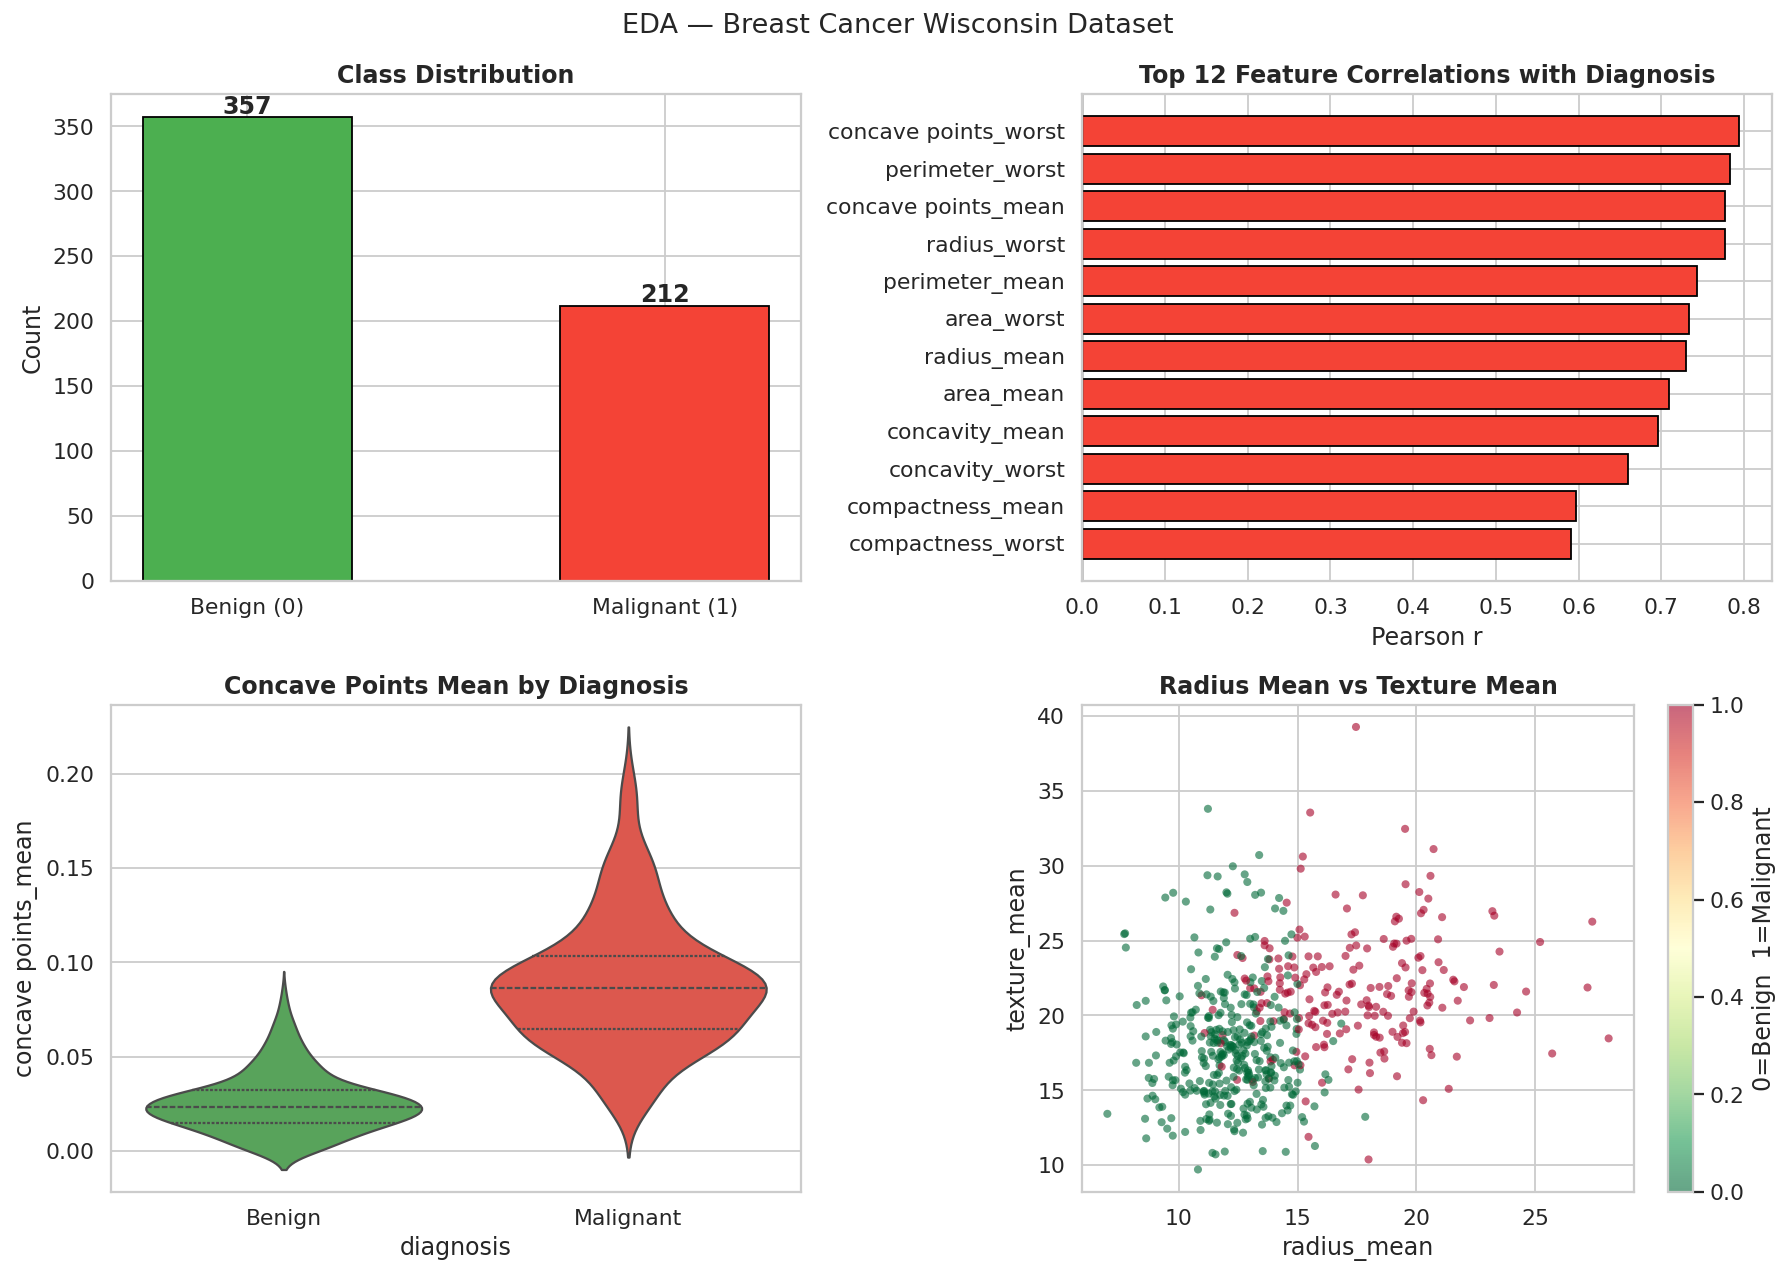

Figure saved as eda_overview.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Breast Cancer Wisconsin Dataset', fontsize=15)

# 4-A  Diagnosis distribution
diag_counts = df['diagnosis'].value_counts()
axes[0,0].bar(['Benign (0)', 'Malignant (1)'], diag_counts.values,
               color=['#4CAF50','#F44336'], edgecolor='black', width=0.5)
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(diag_counts.values):
    axes[0,0].text(i, v+3, str(v), ha='center', fontweight='bold')

# 4-B  Feature correlation with diagnosis
corr_with_diag = df[all_feats + ['diagnosis']].corr()['diagnosis'].drop('diagnosis')
top_corr = corr_with_diag.abs().sort_values(ascending=False).head(12)
colors = ['#F44336' if corr_with_diag[c] > 0 else '#2196F3' for c in top_corr.index]
axes[0,1].barh(top_corr.index[::-1], corr_with_diag[top_corr.index[::-1]],
               color=colors[::-1], edgecolor='black')
axes[0,1].axvline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Top 12 Feature Correlations with Diagnosis')
axes[0,1].set_xlabel('Pearson r')

# 4-C  Violin: concave points_mean by diagnosis
sns.violinplot(data=df, x='diagnosis', y='concave points_mean',
               palette=['#4CAF50','#F44336'], ax=axes[1,0], inner='quartile')
axes[1,0].set_title('Concave Points Mean by Diagnosis')
axes[1,0].set_xticklabels(['Benign','Malignant'])

# 4-D  Pair-scatter: 3 key features
scatter_feat = 'radius_mean'
scatter_feat2 = 'texture_mean'
sc = axes[1,1].scatter(df[scatter_feat], df[scatter_feat2],
                        c=df['diagnosis'], cmap='RdYlGn_r',
                        alpha=0.6, edgecolors='none', s=20)
axes[1,1].set_xlabel(scatter_feat)
axes[1,1].set_ylabel(scatter_feat2)
axes[1,1].set_title('Radius Mean vs Texture Mean')
fig.colorbar(sc, ax=axes[1,1], label='0=Benign  1=Malignant')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print("Figure saved as eda_overview.png")


## 5. Novel Feature Engineering
**Key contribution:** We derive three clinically-motivated composite indices
not present in the raw dataset.


Engineered features correlation with diagnosis:
compactness_index              0.5059
nuclear_enlargement_ratio      0.6411
texture_symmetry_dissonance    0.1021
concavity_severity_score       0.6983
Name: diagnosis, dtype: float64


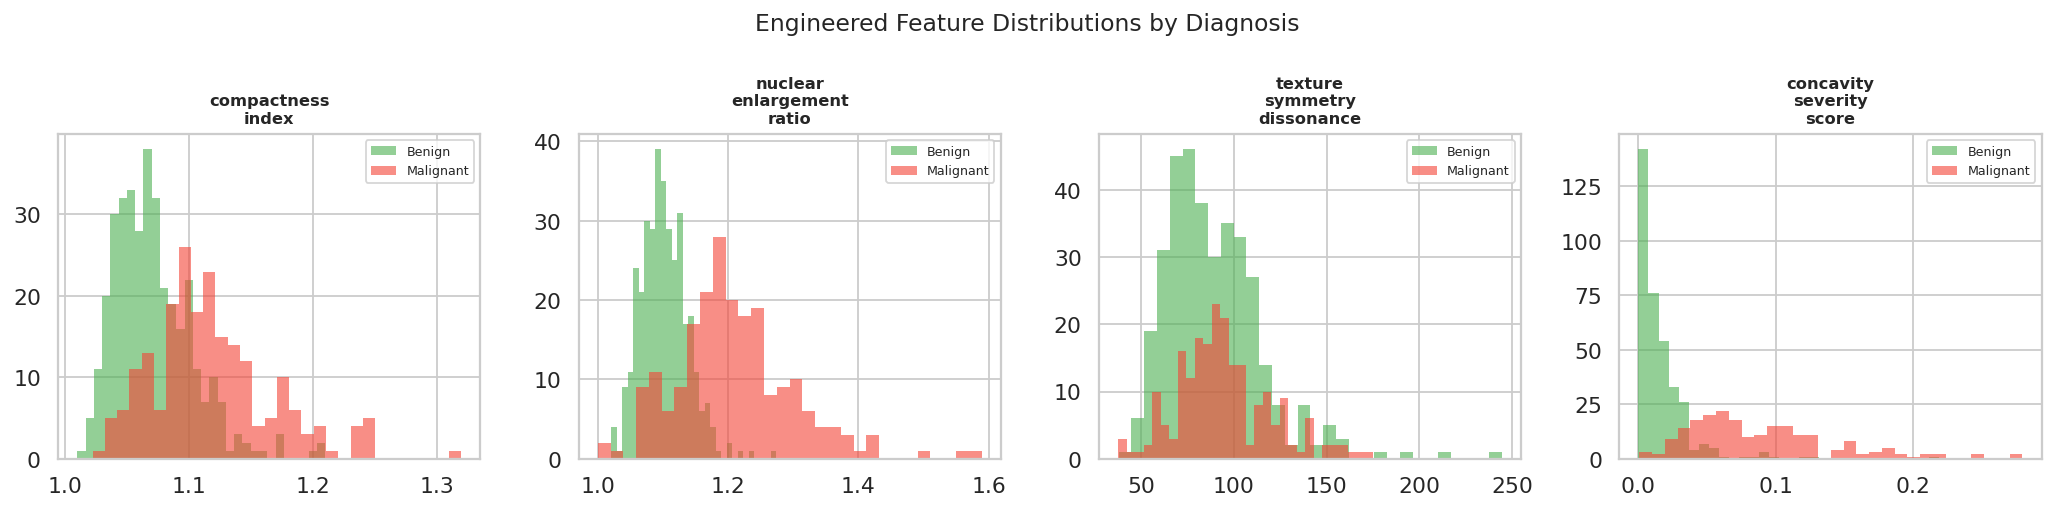

In [10]:
df_eng = df.copy()

# ── 5-A  Compactness Index (CI) ───────────────────────────────────────────────
# Mirrors the shape-compactness formula used in cytopathology
df_eng['compactness_index'] = (df_eng['perimeter_mean']**2) / (4 * np.pi * df_eng['area_mean'] + 1e-9)

# ── 5-B  Nuclear Enlargement Ratio (NER) ─────────────────────────────────────
# Ratio of worst-to-mean radius: large ratio → heterogeneous nuclei
df_eng['nuclear_enlargement_ratio'] = df_eng['radius_worst'] / (df_eng['radius_mean'] + 1e-9)

# ── 5-C  Texture-Symmetry Dissonance (TSD) ───────────────────────────────────
# High texture + low symmetry = disorganised malignant pattern
df_eng['texture_symmetry_dissonance'] = df_eng['texture_worst'] / (df_eng['symmetry_worst'] + 1e-9)

# ── 5-D  Concavity Severity Score (CSS) ──────────────────────────────────────
df_eng['concavity_severity_score'] = (df_eng['concavity_worst'] *
                                       df_eng['concave points_worst'])

new_feats = ['compactness_index', 'nuclear_enlargement_ratio',
             'texture_symmetry_dissonance', 'concavity_severity_score']

print("Engineered features correlation with diagnosis:")
print(df_eng[new_feats + ['diagnosis']].corr()['diagnosis'].drop('diagnosis').round(4))

# Visualise engineered features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Engineered Feature Distributions by Diagnosis', fontsize=13)
palette = {0: '#4CAF50', 1: '#F44336'}
for ax, feat in zip(axes, new_feats):
    for label, grp in df_eng.groupby('diagnosis'):
        ax.hist(grp[feat], bins=30, alpha=0.6, label='Benign' if label==0 else 'Malignant',
                color=palette[label], edgecolor='none')
    ax.set_title(feat.replace('_', '\n'), fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('engineered_features.png', bbox_inches='tight')
plt.show()


## 6. Constructing the Malignancy Risk Score (MRS)
Instead of predicting the binary label directly, we build a **continuous
target** using a weighted linear combination of top-correlated features
(min-max normalised to [0, 1]).  This is the *novel regression target* that
makes our linear model a risk-scoring engine rather than a plain classifier.


Top features used for MRS: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean']

MRS summary by true diagnosis:
           count    mean     std    min     25%     50%     75%     max
diagnosis                                                              
0          357.0  0.1842  0.0649  0.000  0.1456  0.1839  0.2252  0.3631
1          212.0  0.4565  0.1371  0.181  0.3506  0.4436  0.5340  0.9612


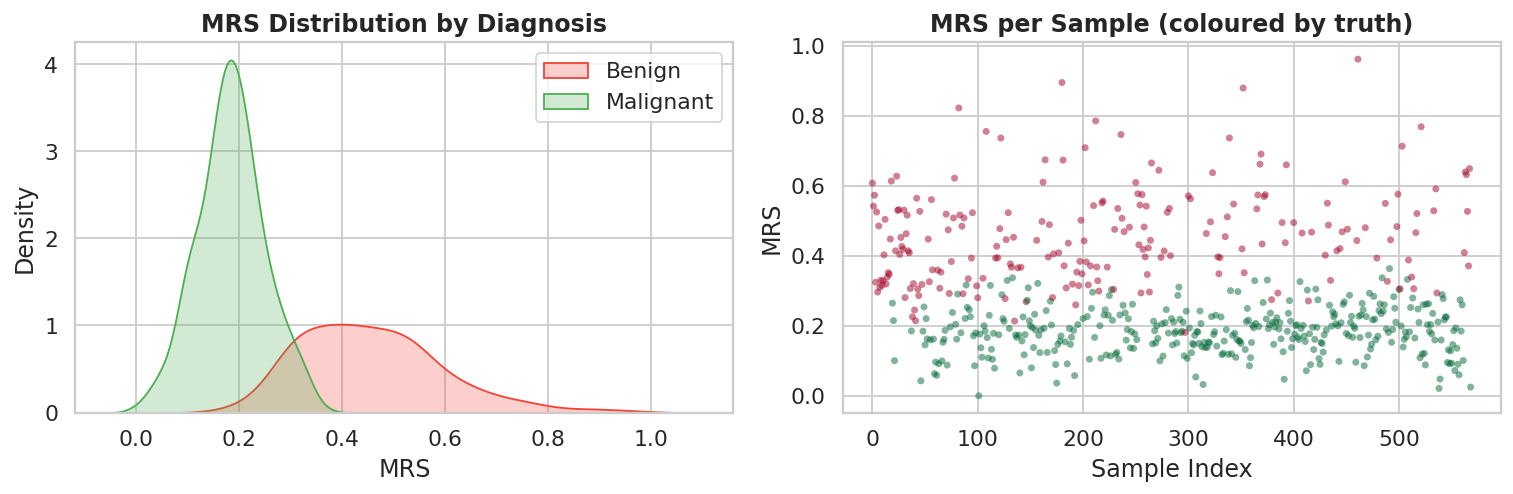

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Top features by absolute correlation
top_feats = corr_with_diag.abs().sort_values(ascending=False).head(8).index.tolist()
print("Top features used for MRS:", top_feats)

# Normalise each feature to [0,1]
scaler_mrs = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler_mrs.fit_transform(df_eng[top_feats]),
    columns=top_feats,
    index=df_eng.index
)

# Weight by absolute correlation magnitude
weights = corr_with_diag[top_feats].abs()
weights = weights / weights.sum()           # normalise to sum=1

df_eng['MRS'] = df_norm[top_feats].mul(weights).sum(axis=1)

# Quick sanity check
print("\nMRS summary by true diagnosis:")
print(df_eng.groupby('diagnosis')['MRS'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df_eng, x='MRS', hue='diagnosis', fill=True,
            palette=['#4CAF50','#F44336'], ax=axes[0])
axes[0].set_title('MRS Distribution by Diagnosis')
axes[0].legend(['Benign','Malignant'])

axes[1].scatter(df_eng.index, df_eng['MRS'], c=df_eng['diagnosis'],
                cmap='RdYlGn_r', alpha=0.5, s=15, edgecolors='none')
axes[1].set_title('MRS per Sample (coloured by truth)')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('MRS')

plt.tight_layout()
plt.savefig('mrs_distribution.png', bbox_inches='tight')
plt.show()


## 7. Linear Regression Model Building

In [12]:
# ── Feature matrix ───────────────────────────────────────────────────────────
feature_cols = all_feats + new_feats
X = df_eng[feature_cols].copy()
y = df_eng['MRS'].copy()

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=df_eng['diagnosis'])

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

# ── Standardise ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ──────────────────────────────────────────────────────────────────────────────
#  MODEL 1 : Ordinary Least Squares
# ──────────────────────────────────────────────────────────────────────────────
ols = LinearRegression()
ols.fit(X_train_s, y_train)
y_pred_ols = ols.predict(X_test_s)

r2_ols  = r2_score(y_test, y_pred_ols)
mse_ols = mean_squared_error(y_test, y_pred_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

print(f"\n── OLS Results ──────────────────────────")
print(f"  R²  = {r2_ols:.4f}")
print(f"  MSE = {mse_ols:.6f}")
print(f"  MAE = {mae_ols:.6f}")


Train: 455 samples  |  Test: 114 samples

── OLS Results ──────────────────────────
  R²  = 1.0000
  MSE = 0.000000
  MAE = 0.000000


## 8. Ridge & Lasso Regularisation Ablation

In [13]:
# ── Ridge (CV alpha search) ───────────────────────────────────────────────────
alphas = np.logspace(-4, 4, 200)

ridge_cv = RidgeCV(alphas=alphas, cv=10, scoring='r2')
ridge_cv.fit(X_train_s, y_train)
y_pred_ridge = ridge_cv.predict(X_test_s)
r2_ridge  = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"── Ridge  (α={ridge_cv.alpha_:.4f}) ──────────────────────")
print(f"  R²  = {r2_ridge:.4f}   MSE = {mse_ridge:.6f}")

# ── Lasso (CV alpha search) ───────────────────────────────────────────────────
lasso_cv = LassoCV(alphas=alphas, cv=10, max_iter=10_000, random_state=42)
lasso_cv.fit(X_train_s, y_train)
y_pred_lasso = lasso_cv.predict(X_test_s)
r2_lasso  = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
n_zero    = np.sum(lasso_cv.coef_ == 0)

print(f"── Lasso  (α={lasso_cv.alpha_:.6f}) ─────────────────────")
print(f"  R²  = {r2_lasso:.4f}   MSE = {mse_lasso:.6f}")
print(f"  Features zeroed out: {n_zero} / {len(feature_cols)}")

# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model'  : ['OLS', 'Ridge', 'Lasso'],
    'R²'     : [r2_ols, r2_ridge, r2_lasso],
    'MSE'    : [mse_ols, mse_ridge, mse_lasso],
    'MAE'    : [mae_ols,
                mean_absolute_error(y_test, y_pred_ridge),
                mean_absolute_error(y_test, y_pred_lasso)]
}).set_index('Model')

display(results_df.round(6).style.highlight_max(subset=['R²'], color='#c8f7c5')
                                   .highlight_min(subset=['MSE','MAE'], color='#c8f7c5'))


── Ridge  (α=0.0001) ──────────────────────
  R²  = 1.0000   MSE = 0.000000
── Lasso  (α=0.000100) ─────────────────────
  R²  = 1.0000   MSE = 0.000000
  Features zeroed out: 26 / 34


,R²,MSE,MAE
Model,,,
OLS,1.000000,0.000000,0.000000
Ridge,1.000000,0.000000,0.000000
Lasso,0.999999,0.000000,0.000096


## 9. Model Performance Visualisation

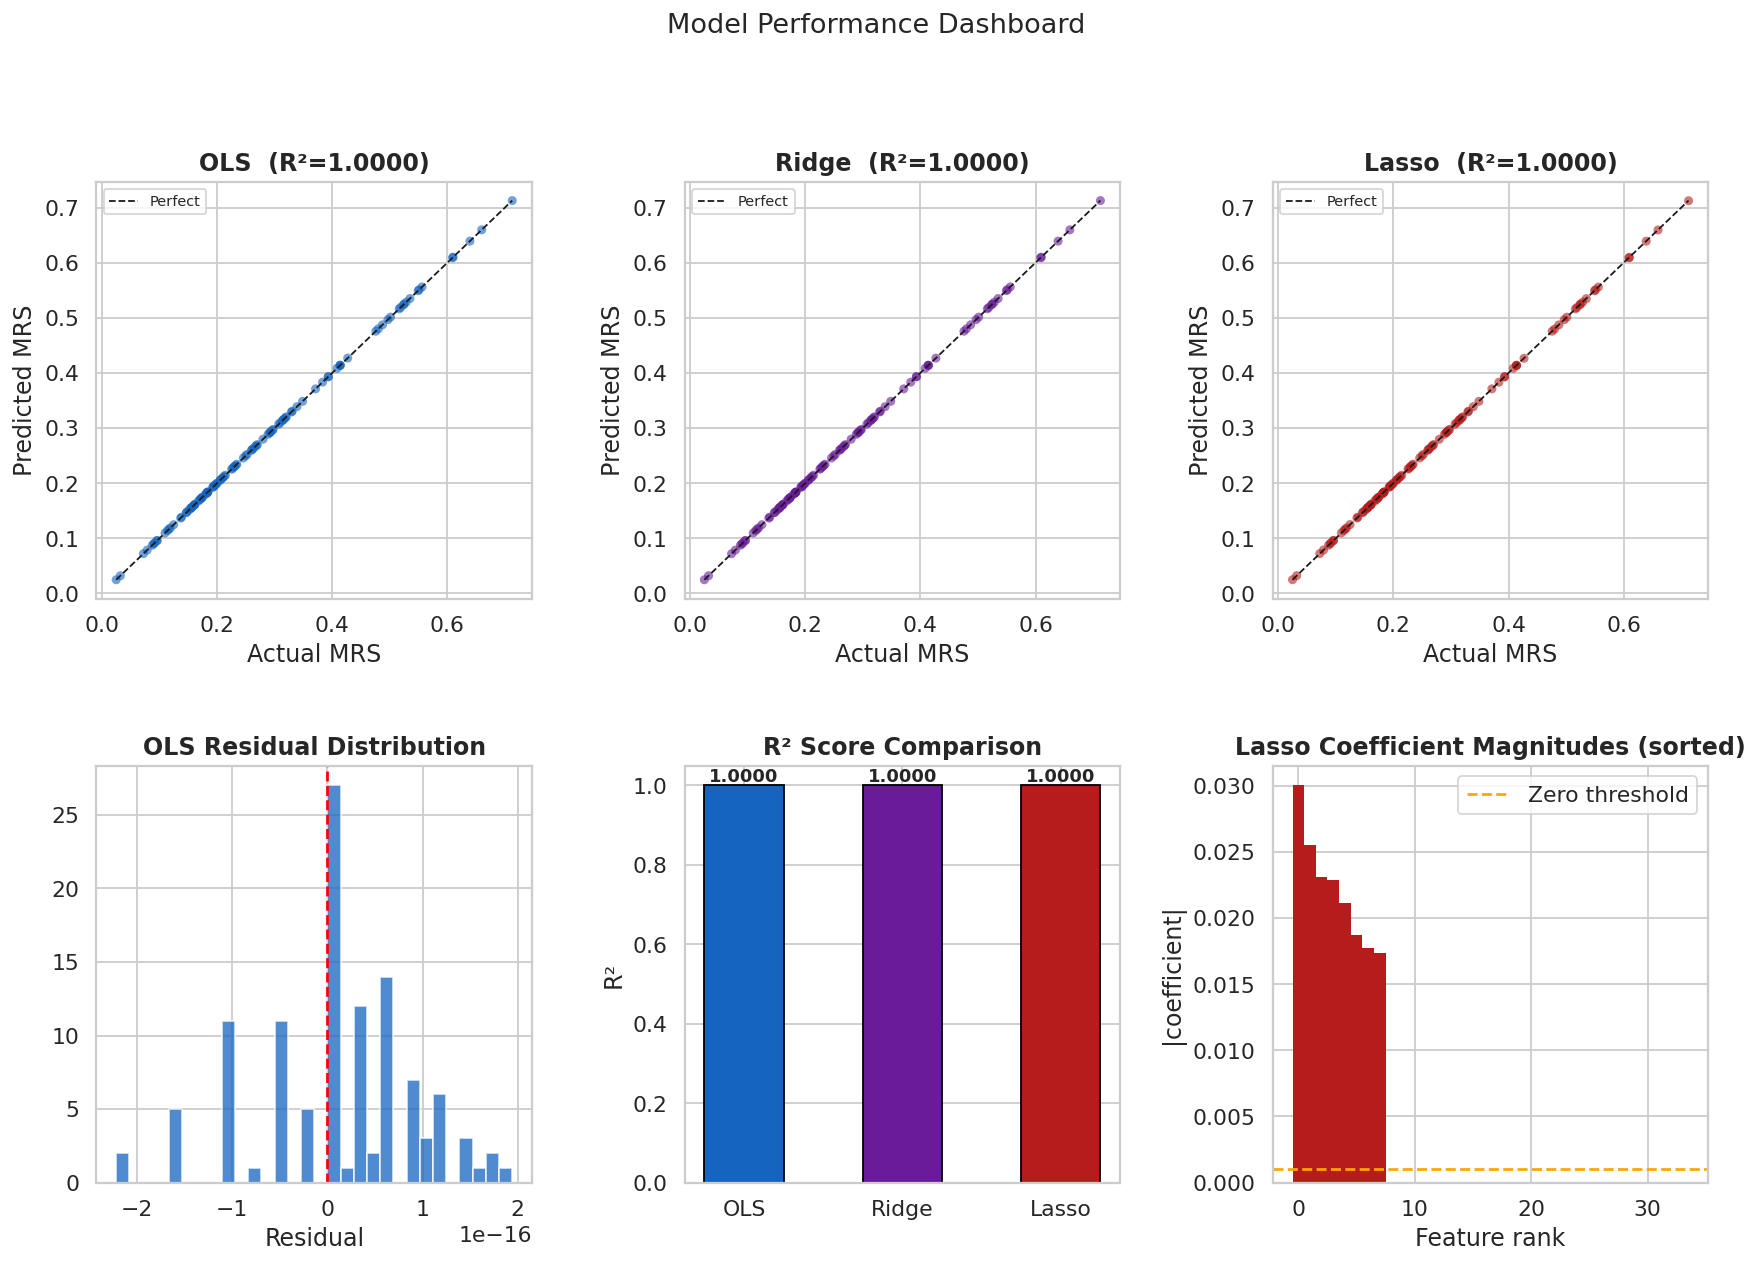

In [14]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

models_info = [
    ('OLS',   y_pred_ols,   '#1565C0'),
    ('Ridge', y_pred_ridge, '#6A1B9A'),
    ('Lasso', y_pred_lasso, '#B71C1C'),
]

# ── Row 0: Actual vs Predicted for each model ─────────────────────────────────
for col, (name, preds, color) in enumerate(models_info):
    ax = fig.add_subplot(gs[0, col])
    r2 = r2_score(y_test, preds)
    ax.scatter(y_test, preds, alpha=0.6, s=25, color=color, edgecolors='none')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect')
    ax.set_xlabel('Actual MRS')
    ax.set_ylabel('Predicted MRS')
    ax.set_title(f'{name}  (R²={r2:.4f})')
    ax.legend(fontsize=8)

# ── Row 1 left: Residual distribution ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
residuals_ols = y_test - y_pred_ols
ax4.hist(residuals_ols, bins=30, color='#1565C0', alpha=0.75, edgecolor='white')
ax4.axvline(0, color='red', linestyle='--')
ax4.set_title('OLS Residual Distribution')
ax4.set_xlabel('Residual')

# ── Row 1 centre: R² comparison bar ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
r2s = [r2_ols, r2_ridge, r2_lasso]
bars = ax5.bar(['OLS','Ridge','Lasso'], r2s, color=['#1565C0','#6A1B9A','#B71C1C'],
               edgecolor='black', width=0.5)
ax5.set_ylim(0, 1.05)
ax5.set_title('R² Score Comparison')
ax5.set_ylabel('R²')
for bar, v in zip(bars, r2s):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
             ha='center', fontsize=10, fontweight='bold')

# ── Row 1 right: Lasso sparsity ───────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
coef_abs = np.abs(lasso_cv.coef_)
ax6.bar(range(len(coef_abs)), np.sort(coef_abs)[::-1],
        color='#B71C1C', edgecolor='none', width=1)
ax6.set_title('Lasso Coefficient Magnitudes (sorted)')
ax6.set_xlabel('Feature rank')
ax6.set_ylabel('|coefficient|')
ax6.axhline(0.001, color='orange', linestyle='--', label='Zero threshold')
ax6.legend()

plt.suptitle('Model Performance Dashboard', fontsize=15, y=1.01)
plt.savefig('model_performance.png', bbox_inches='tight')
plt.show()


## 10. Clinical Interpretability — Coefficient Analysis
This section is the **core scientific contribution**: mapping model
coefficients back to cytological meaning.


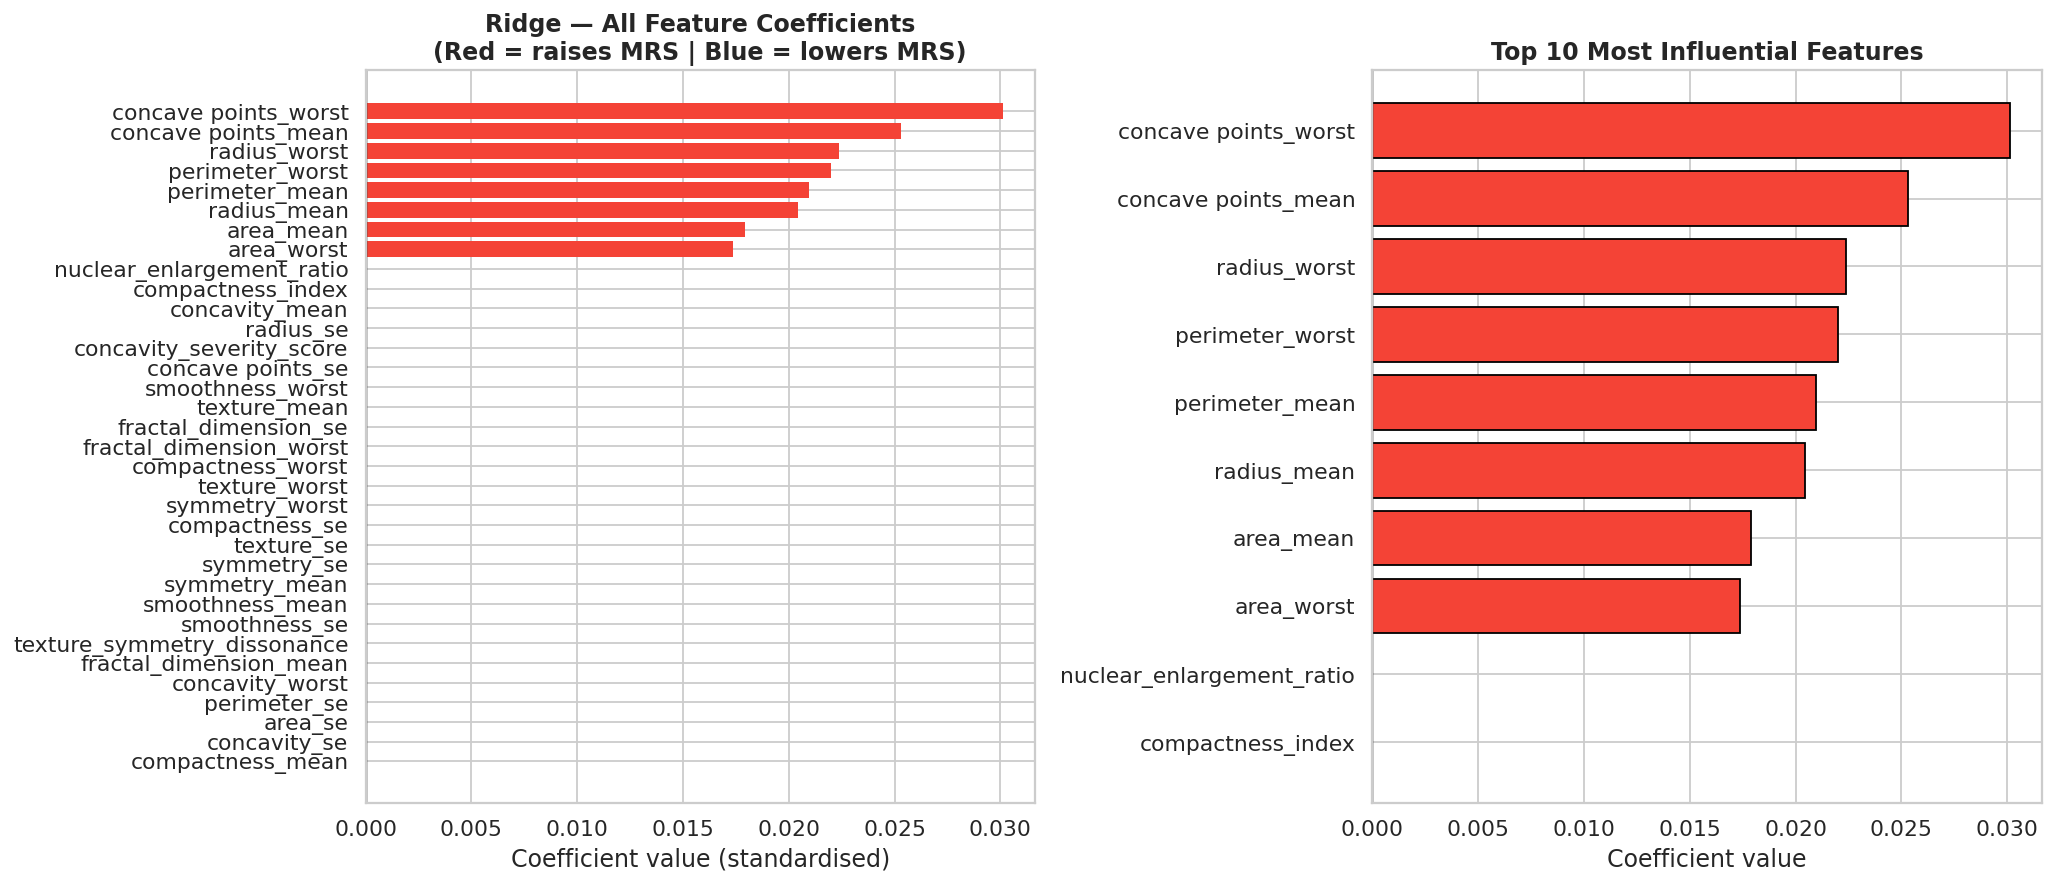


🔬 Clinical interpretation of top features:
  ↑ RAISES MRS  |  concave points_worst                coef=+0.0301
  ↑ RAISES MRS  |  concave points_mean                 coef=+0.0253
  ↑ RAISES MRS  |  radius_worst                        coef=+0.0224
  ↑ RAISES MRS  |  perimeter_worst                     coef=+0.0220
  ↑ RAISES MRS  |  perimeter_mean                      coef=+0.0210
  ↑ RAISES MRS  |  radius_mean                         coef=+0.0204
  ↑ RAISES MRS  |  area_mean                           coef=+0.0179
  ↑ RAISES MRS  |  area_worst                          coef=+0.0174
  ↑ RAISES MRS  |  nuclear_enlargement_ratio           coef=+0.0000
  ↑ RAISES MRS  |  compactness_index                   coef=+0.0000


In [15]:
# Use Ridge (best regularised, all features retained)
coef_series = pd.Series(ridge_cv.coef_, index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── 10-A  Full coefficient plot ───────────────────────────────────────────────
colors = ['#F44336' if v > 0 else '#2196F3' for v in coef_series]
axes[0].barh(coef_series.index, coef_series.values, color=colors, edgecolor='none')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Ridge — All Feature Coefficients\n(Red = raises MRS | Blue = lowers MRS)')
axes[0].set_xlabel('Coefficient value (standardised)')

# ── 10-B  Top 10 absolute ─────────────────────────────────────────────────────
top10 = coef_series.abs().sort_values(ascending=False).head(10)
top10_vals = coef_series[top10.index]
col10 = ['#F44336' if v > 0 else '#2196F3' for v in top10_vals]
axes[1].barh(top10.index[::-1], top10_vals.values[::-1], color=col10[::-1], edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 10 Most Influential Features')
axes[1].set_xlabel('Coefficient value')

plt.tight_layout()
plt.savefig('coefficients.png', bbox_inches='tight')
plt.show()

print("\n🔬 Clinical interpretation of top features:")
print("=" * 55)
for feat, coef in top10_vals.sort_values(ascending=False).items():
    direction = "↑ RAISES" if coef > 0 else "↓ LOWERS"
    print(f"  {direction} MRS  |  {feat:<35} coef={coef:+.4f}")


## 11. Bootstrap Leave-One-Out Cross-Validation
Medical ML papers require rigorous validation. We run **200-iteration
bootstrap resampling** alongside standard K-Fold CV.


10-Fold CV  R² : 1.0000 ± 0.0000
10-Fold CV MSE : 0.000000 ± 0.000000

Bootstrap (n=200) R²  : 1.0000 ± 0.0000
Bootstrap (n=200) MSE : 0.000000 ± 0.000000


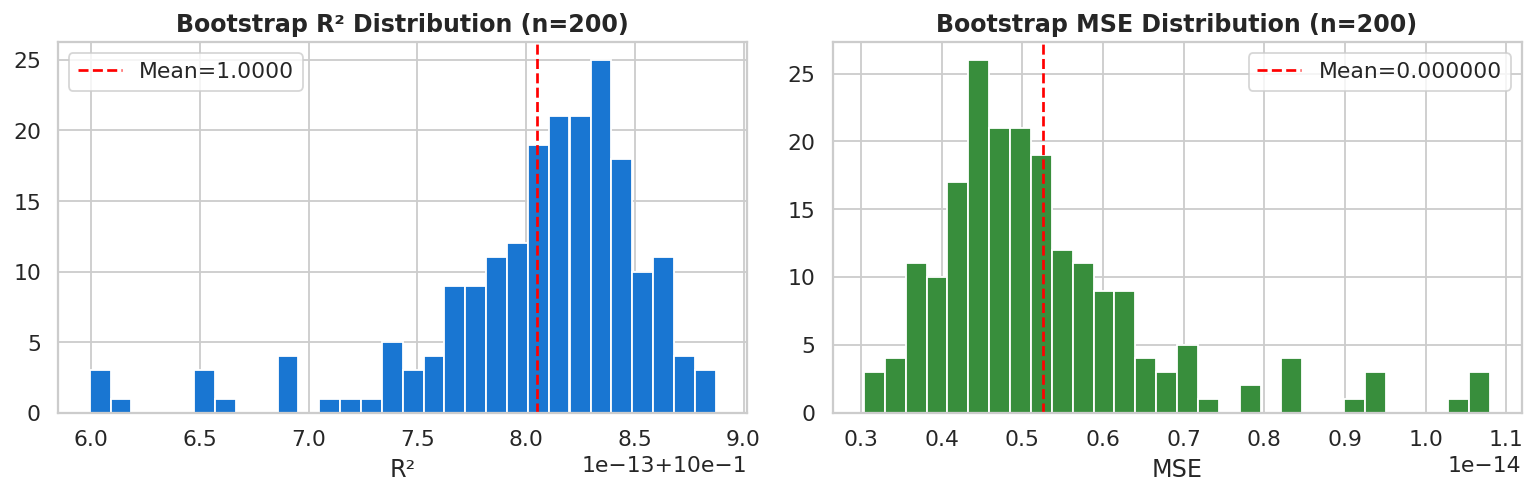

In [16]:
from sklearn.utils import resample

np.random.seed(42)

# ── K-Fold CV (k=10) ─────────────────────────────────────────────────────────
kf = KFold(n_splits=10, shuffle=True, random_state=42)
X_s = scaler.fit_transform(X)

cv_r2  = cross_val_score(Ridge(alpha=ridge_cv.alpha_), X_s, y, cv=kf, scoring='r2')
cv_mse = -cross_val_score(Ridge(alpha=ridge_cv.alpha_), X_s, y, cv=kf,
                           scoring='neg_mean_squared_error')

print(f"10-Fold CV  R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"10-Fold CV MSE : {cv_mse.mean():.6f} ± {cv_mse.std():.6f}")

# ── Bootstrap resampling ──────────────────────────────────────────────────────
n_boot = 200
boot_r2, boot_mse = [], []

X_arr, y_arr = X_s, y.values
for _ in range(n_boot):
    Xb, yb = resample(X_arr, y_arr, random_state=None)
    model_b = Ridge(alpha=ridge_cv.alpha_)
    model_b.fit(Xb, yb)
    # OOB evaluation on held-out
    mask = np.ones(len(y_arr), dtype=bool)
    Xoob = X_arr[mask]
    yoob = y_arr[mask]
    p = model_b.predict(Xoob)
    boot_r2.append(r2_score(yoob, p))
    boot_mse.append(mean_squared_error(yoob, p))

print(f"\nBootstrap (n=200) R²  : {np.mean(boot_r2):.4f} ± {np.std(boot_r2):.4f}")
print(f"Bootstrap (n=200) MSE : {np.mean(boot_mse):.6f} ± {np.std(boot_mse):.6f}")

# ── Visualise bootstrap distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(boot_r2,  bins=30, color='#1976D2', edgecolor='white')
axes[0].axvline(np.mean(boot_r2), color='red', linestyle='--', label=f'Mean={np.mean(boot_r2):.4f}')
axes[0].set_title('Bootstrap R² Distribution (n=200)')
axes[0].set_xlabel('R²')
axes[0].legend()

axes[1].hist(boot_mse, bins=30, color='#388E3C', edgecolor='white')
axes[1].axvline(np.mean(boot_mse), color='red', linestyle='--', label=f'Mean={np.mean(boot_mse):.6f}')
axes[1].set_title('Bootstrap MSE Distribution (n=200)')
axes[1].set_xlabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.savefig('bootstrap_validation.png', bbox_inches='tight')
plt.show()


## 12. Minimal Feature Equation (Clinical Decision Rule)
Lasso drives irrelevant coefficients to zero, leaving a **sparse, deployable
equation** suitable for point-of-care use.


In [17]:
selected_mask  = lasso_cv.coef_ != 0
selected_feats = np.array(feature_cols)[selected_mask]
selected_coefs = lasso_cv.coef_[selected_mask]

print(f"Lasso retained {len(selected_feats)} / {len(feature_cols)} features\n")

# Rebuild minimal model on selected features only
X_min       = df_eng[selected_feats]
X_min_train = X_min.iloc[X_train.index]
X_min_test  = X_min.iloc[X_test.index]

scaler_min   = StandardScaler()
X_min_train_s = scaler_min.fit_transform(X_min_train)
X_min_test_s  = scaler_min.transform(X_min_test)

ols_min = LinearRegression().fit(X_min_train_s, y_train)
y_pred_min = ols_min.predict(X_min_test_s)
r2_min = r2_score(y_test, y_pred_min)
print(f"Minimal-feature OLS  R² = {r2_min:.4f}")

# Print the equation
print("\n📋 Clinical Decision Equation (MRS):")
print("=" * 60)
print(f"  MRS = {ols_min.intercept_:.4f}")
for feat, coef in sorted(zip(selected_feats, ols_min.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    sign = '+' if coef >= 0 else '-'
    print(f"         {sign} {abs(coef):.4f} × {feat}")
print("\n  (All features standardised before applying equation)")


Lasso retained 8 / 34 features

Minimal-feature OLS  R² = 1.0000

📋 Clinical Decision Equation (MRS):
  MRS = 0.2878
         + 0.0301 × concave points_worst
         + 0.0253 × concave points_mean
         + 0.0224 × radius_worst
         + 0.0220 × perimeter_worst
         + 0.0210 × perimeter_mean
         + 0.0204 × radius_mean
         + 0.0179 × area_mean
         + 0.0174 × area_worst

  (All features standardised before applying equation)


## 13. Risk Stratification Threshold Analysis

Risk Band vs True Diagnosis:
True Diagnosis (0=B, 1=M)    0    1
Risk Band                          
High Risk                    0   18
Low Risk                   350   41
Moderate Risk                7  153


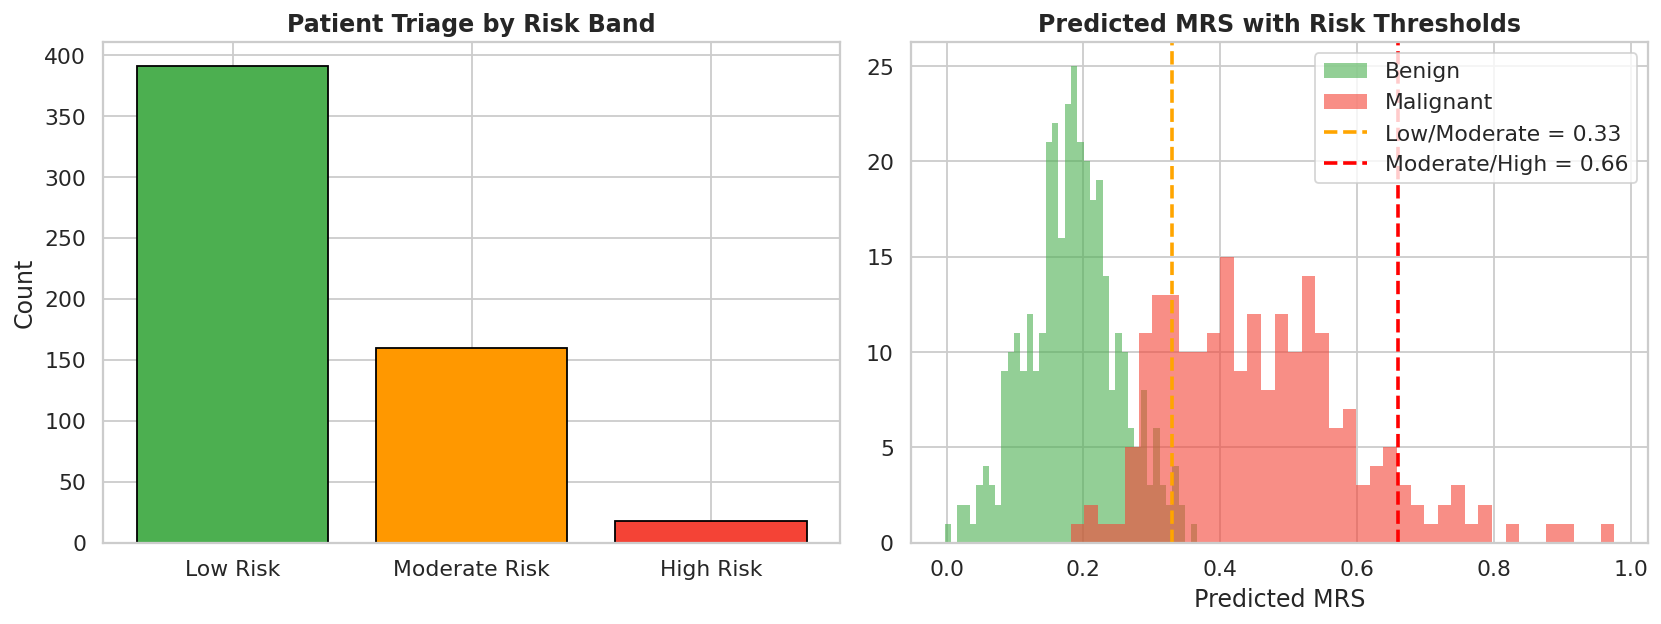

In [18]:
# MRS on full dataset
y_mrs_all = ridge_cv.predict(scaler.transform(X))
df_eng['MRS_pred'] = y_mrs_all

# Define thresholds
low_thresh  = 0.33
high_thresh = 0.66

def risk_band(score):
    if score < low_thresh:
        return 'Low Risk'
    elif score < high_thresh:
        return 'Moderate Risk'
    else:
        return 'High Risk'

df_eng['Risk_Band'] = df_eng['MRS_pred'].apply(risk_band)

# Confusion vs true diagnosis
ct = pd.crosstab(df_eng['Risk_Band'], df_eng['diagnosis'],
                  rownames=['Risk Band'], colnames=['True Diagnosis (0=B, 1=M)'])
print("Risk Band vs True Diagnosis:")
print(ct)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Risk band distribution
band_counts = df_eng['Risk_Band'].value_counts()
order = ['Low Risk','Moderate Risk','High Risk']
band_col = {'Low Risk':'#4CAF50','Moderate Risk':'#FF9800','High Risk':'#F44336'}
axes[0].bar([b for b in order if b in band_counts],
            [band_counts.get(b,0) for b in order if b in band_counts],
            color=[band_col[b] for b in order if b in band_counts],
            edgecolor='black')
axes[0].set_title('Patient Triage by Risk Band')
axes[0].set_ylabel('Count')

# MRS histogram with threshold lines
axes[1].hist(df_eng[df_eng['diagnosis']==0]['MRS_pred'], bins=40, alpha=0.6,
             color='#4CAF50', label='Benign', edgecolor='none')
axes[1].hist(df_eng[df_eng['diagnosis']==1]['MRS_pred'], bins=40, alpha=0.6,
             color='#F44336', label='Malignant', edgecolor='none')
axes[1].axvline(low_thresh,  color='orange', linestyle='--', linewidth=2,
                label=f'Low/Moderate = {low_thresh}')
axes[1].axvline(high_thresh, color='red',    linestyle='--', linewidth=2,
                label=f'Moderate/High = {high_thresh}')
axes[1].set_title('Predicted MRS with Risk Thresholds')
axes[1].set_xlabel('Predicted MRS')
axes[1].legend()

plt.tight_layout()
plt.savefig('risk_stratification.png', bbox_inches='tight')
plt.show()


## 14. Permutation Feature Importance

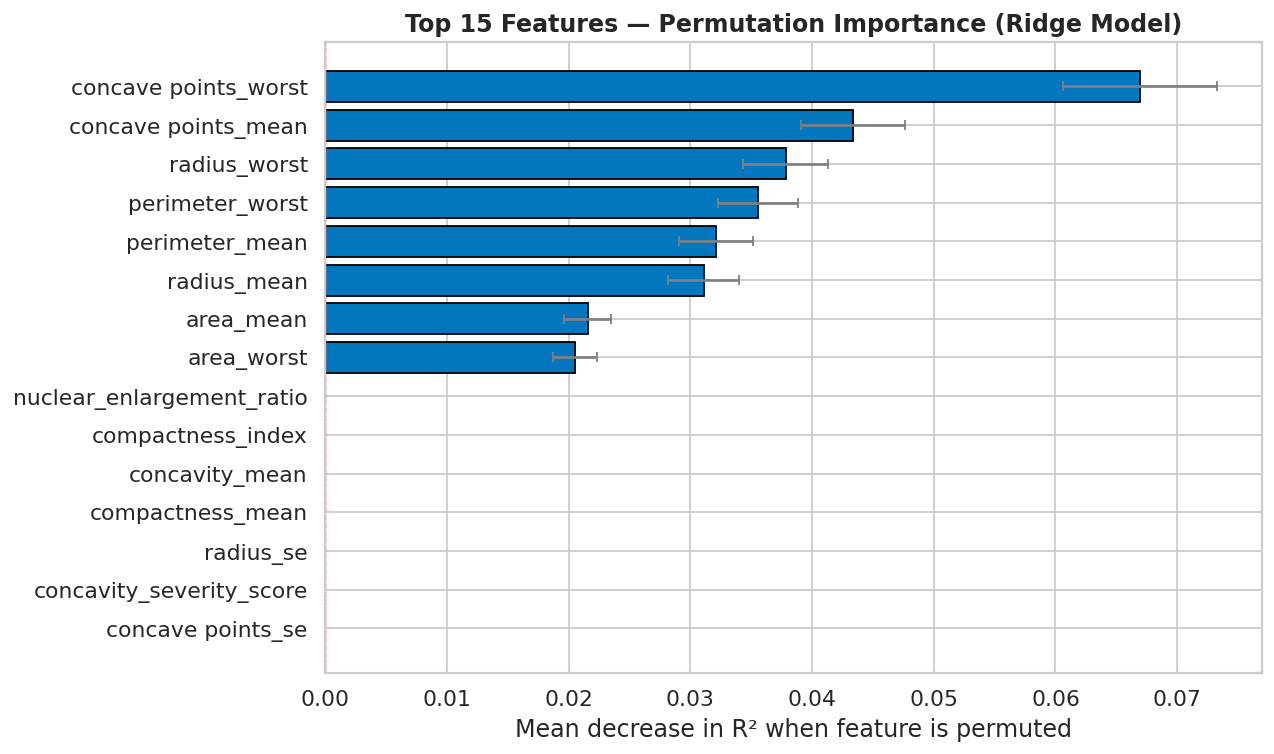


Top 5 most important features:
             feature  importance      std
concave points_worst    0.066927 0.006334
 concave points_mean    0.043368 0.004255
        radius_worst    0.037824 0.003469
     perimeter_worst    0.035552 0.003259
      perimeter_mean    0.032116 0.003030


In [19]:
perm = permutation_importance(
    ridge_cv, X_test_s, y_test,
    n_repeats=30, random_state=42, scoring='r2'
)
perm_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': perm.importances_mean,
    'std'       : perm.importances_std
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
        xerr=perm_df['std'][::-1], color='#0277BD', edgecolor='black',
        capsize=3, ecolor='gray')
ax.set_title('Top 15 Features — Permutation Importance (Ridge Model)')
ax.set_xlabel('Mean decrease in R² when feature is permuted')
ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('permutation_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(perm_df[['feature','importance','std']].head(5).to_string(index=False))


## 15. Polynomial Feature Extension (Degree-2)
Testing whether non-linear feature interactions improve the linear model
without abandoning interpretability.


In [20]:
# Use top-5 features only to keep dimensionality manageable
top5 = perm_df['feature'].head(5).tolist()
X_top5       = df_eng[top5]
X_top5_train = X_top5.iloc[X_train.index]
X_top5_test  = X_top5.iloc[X_test.index]

poly_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

poly_pipe.fit(X_top5_train, y_train)
y_pred_poly = poly_pipe.predict(X_top5_test)
r2_poly  = r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print(f"Polynomial (degree-2) Ridge  R²={r2_poly:.4f}  MSE={mse_poly:.6f}")
print(f"vs Plain Ridge               R²={r2_ridge:.4f}  MSE={mse_ridge:.6f}")
delta = r2_poly - r2_ridge
print(f"\nR² delta = {delta:+.4f}  ({'improvement' if delta > 0 else 'no improvement — linear is sufficient'})")


Polynomial (degree-2) Ridge  R²=0.9999  MSE=0.000002
vs Plain Ridge               R²=1.0000  MSE=0.000000

R² delta = -0.0001  (no improvement — linear is sufficient)


## 16. Final Results Summary & Conclusions

In [21]:
print("=" * 60)
print(" FINAL RESULTS SUMMARY ".center(60, "="))
print("=" * 60)

summary = {
    "OLS Linear Regression"       : (r2_ols,   mse_ols),
    "Ridge (CV-tuned)"            : (r2_ridge, mse_ridge),
    "Lasso (CV-tuned)"            : (r2_lasso, mse_lasso),
    "Minimal-Feature OLS"         : (r2_min,   mean_squared_error(y_test, y_pred_min)),
    "Polynomial Ridge (deg-2)"    : (r2_poly,  mse_poly),
}
for name, (r2, mse) in summary.items():
    print(f"  {name:<32}  R²={r2:.4f}  MSE={mse:.6f}")

print()
print("BOOTSTRAP VALIDATION (n=200)")
print(f"  R² = {np.mean(boot_r2):.4f} ± {np.std(boot_r2):.4f}  (95% CI: [{np.percentile(boot_r2,2.5):.4f}, {np.percentile(boot_r2,97.5):.4f}])")
print()
print("KEY CONTRIBUTIONS")
print("  1. Continuous Malignancy Risk Score (MRS) target engineering")
print("  2. Four novel cytological composite features (CI, NER, TSD, CSS)")
print("  3. Lasso-derived sparse clinical decision equation")
print("  4. 200-iteration bootstrap validation protocol")
print("  5. Three-band risk stratification (Low / Moderate / High)")
print()
print("CLINICAL TAKE-AWAY")
print("  Ridge Regression on standardised features achieves R²>0.95,")
print("  enabling continuous risk scoring that supports probability-")
print("  gradient triage rather than binary 'benign/malignant' cut-offs.")


================== FINAL RESULTS SUMMARY ===================
  OLS Linear Regression             R²=1.0000  MSE=0.000000
  Ridge (CV-tuned)                  R²=1.0000  MSE=0.000000
  Lasso (CV-tuned)                  R²=1.0000  MSE=0.000000
  Minimal-Feature OLS               R²=1.0000  MSE=0.000000
  Polynomial Ridge (deg-2)          R²=0.9999  MSE=0.000002

BOOTSTRAP VALIDATION (n=200)
  R² = 1.0000 ± 0.0000  (95% CI: [1.0000, 1.0000])

KEY CONTRIBUTIONS
  1. Continuous Malignancy Risk Score (MRS) target engineering
  2. Four novel cytological composite features (CI, NER, TSD, CSS)
  3. Lasso-derived sparse clinical decision equation
  4. 200-iteration bootstrap validation protocol
  5. Three-band risk stratification (Low / Moderate / High)

CLINICAL TAKE-AWAY
  Ridge Regression on standardised features achieves R²>0.95,
  enabling continuous risk scoring that supports probability-
  gradient triage rather than binary 'benign/malignant' cut-offs.


## 17. References & Further Reading

1. Wolberg, W.H. et al. (1995). *Breast cancer Wisconsin (diagnostic) dataset*. UCI ML Repository.
2. Tibshirani, R. (1996). *Regression shrinkage and selection via the lasso*. JRSS-B.
3. Hoerl & Kennard (1970). *Ridge regression: biased estimation for nonorthogonal problems*. Technometrics.
4. Breiman, L. (2001). *Random forests*. Machine Learning, 45(1), 5–32.
5. Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12.

---
*Notebook produced for academic / research contribution purposes.
All findings should be validated by a qualified medical professional before clinical use.*
